# Check single source in DP1 for DCR

Author: Maya Redden, msredden@stanford.edu

In [1]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate


def apply_filter(wvl, data, band = 'g', rm_leakage = True):
    '''
    wvl - a list of the wavelengths in angstroms
    data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
    returns data with the band filter applied to each SED
    '''
    
    filter_file = f'filter_files/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    # remove filter leakage: set lower bound of filter to 0.001 throughput
    if rm_leakage:
        leakage_mask = filter_band[1] < 0.001
        filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
    func = interp1d(filter_band[0], filter_band[1])
    SED_filter = func(wvl)
    
    return data * SED_filter

In [2]:
# If data is downloaded from the RSP...
# Load DP1 data
# Need a .vot table of source catalog entries of all visits of a single object
# Need a .vot table of all visits in the survey that overlap with the object


source_file = 'DP1_tests/dp1_test_gr_5t7_source.vot'
source_table = parse(source_file)
source_table = source_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
source_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17']
source_column_names = ['band','calibFlux','calibFluxErr','coord_dec','coord_ra','dec','decErr','ixx','ixxPSF','ixy','ixyPSF','iyy','iyyPSF','psfFlux','psfFluxErr','ra','raErr','visit']

for i, col in enumerate(source_default_column_names):
    source_table.rename_column(col, source_column_names[i])



visit_file = 'DP1_tests/dp1_ecdfs_allvisits.vot'
visit_table = parse(visit_file)
visit_table = visit_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
visit_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10']
visit_column_names = ['airmass','altitude','azimuth','band','dec','expTime','ra','skyRotation','visit','zenithDistance','expMidptMJD']

for i, col in enumerate(visit_default_column_names):
    visit_table.rename_column(col, visit_column_names[i])



In [3]:
# Getting data using the tap service on the RSP:

# from lsst.rsp import get_tap_service
# service = get_tap_service("tap")

# ra = 53.161541666666665 #deg
# dec = -28.160638888888887 #deg
# search_radius = 3 #arcsec

# query = f"""SELECT band,
#             calibFlux,
#             calibFluxErr,
#             coord_dec,
#             coord_ra,
#             dec,
#             decErr,
#             ixx,
#             ixxPSF,
#             ixy,
#             ixyPSF,
#             iyy,
#             iyyPSF,
#             psfFlux,
#             psfFluxErr,
#             ra,
#             raErr,
#             visit 
#     FROM dp1.Source 
#     WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""

# job = service.submit_job(query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# source_table = job.fetch_result().to_table()


# visits = source_table['visit']
# visit_string = "','".join(map(str, visits))

# visit_query = f"""SELECT airmass,altitude,azimuth,band,dec,expTime,ra,skyRotation,visit,zenithDistance,expMidptMJD 
# FROM dp1.Visit 
# WHERE visit IN ('{visit_string}')"""


# job = service.submit_job(visit_query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# visit_table = job.fetch_result().to_table()


In [4]:
#Remove the any source entries found in the same visit, there should be only one source detected for each visit:

visit_IDs = source_table['visit']

has_duplicates = len(visit_IDs) != len(np.unique(visit_IDs))
print("Any duplicates?", has_duplicates)

vals, counts = np.unique(visit_IDs, return_counts=True)
duplicates = vals[counts > 1]
print("Duplicated visits:", duplicates)

source_mask = np.isin(source_table['visit'], duplicates)
source_table = source_table[~source_mask]

Any duplicates? False
Duplicated visits: col_17
------


In [6]:
# Create a master table by joining the source and visit tables

from astropy.table import Table, join

master_all = join(source_table, visit_table, keys = 'visit')
print(master_all.colnames)

['band_1', 'calibFlux', 'calibFluxErr', 'coord_dec', 'coord_ra', 'dec_1', 'decErr', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy', 'iyyPSF', 'psfFlux', 'psfFluxErr', 'ra_1', 'raErr', 'visit', 'ROW_IDX_1', 'ROW_NUM_1', 'airmass', 'altitude', 'azimuth', 'band_2', 'dec_2', 'expTime', 'ra_2', 'skyRotation', 'zenithDistance', 'expMidptMJD', 'ROW_IDX_2', 'ROW_NUM_2']


Mean coordinates:  53.16153181 -28.16062424


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


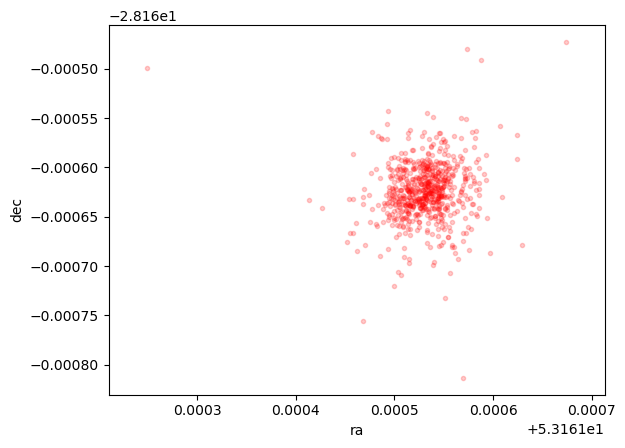

Clipped distribution of points:


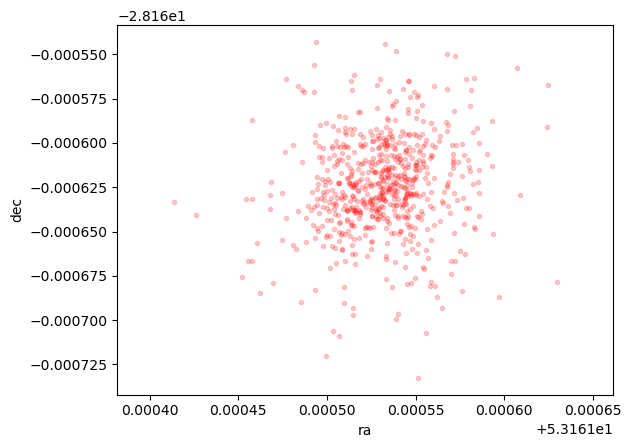

In [7]:
# Plot to check the distribution of visits looks as expected for a single object (limited to a few arcsec)
# If there are outliers, adjust the clipping radius below as needed

center_ra = np.median(master_all['ra_1'])
center_dec = np.median(master_all['dec_1'])

print('Mean coordinates: ', np.round(center_ra, 8), np.round(center_dec, 8))

plt.plot(master_all['ra_1'], master_all['dec_1'], 'r.', alpha = 0.2)
plt.xlabel('ra')
plt.ylabel('dec')
plt.axis('equal')
plt.show()
plt.close()


# create a mask to clip out the outliers:
clipping_radius = 0.00012 # degrees, 0.0001 is ~0.36 arcsec

mask = ((master_all['ra_1'] - center_ra)**2 + (master_all['dec_1'] - center_dec)**2) < (clipping_radius)**2
master = master_all[mask]

# print('Number of points after clipping: ', len(master))
print('Clipped distribution of points:')

plt.plot(master['ra_1'], master['dec_1'], 'r.', alpha = 0.2)
plt.xlabel('ra')
plt.ylabel('dec')
plt.axis('equal')
plt.show()

In [8]:
# Add a few columns to the master table: zenith RA/Dec, parallactic angle, and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction


def parallactic_angle_from_radec(ra, dec, mjd, lat = -30.244633 * u.deg, lon = -70.74941 * u.deg, height=2647*u.m * u.deg, sidereal_kind='apparent'):
    """
    Compute parallactic angle q (Angle) for given RA/Dec and observing site/time.

    Parameters
    ----------
    ra : astropy.units.Quantity or array-like (angle) -- e.g. 120*u.deg or [..]*u.deg
    dec: astropy.units.Quantity (angle)
    mjd: float or array-like (MJD)
    lat : astropy.units.Quantity (angle) -- observer latitude (positive north)
    lon : astropy.units.Quantity (angle) -- observer longitude (east positive; astropy accepts this)
    height: astropy.units.Quantity (length), optional, default 0*m
    sidereal_kind: 'apparent' or 'mean' (which sidereal time to use)

    Returns
    -------
    q : astropy.units.Quantity (angle) parallactic angle in radians (use .to(u.deg) to show degrees)
    """
    # ensure astropy Quantities
    ra = Angle(ra)
    dec = Angle(dec)
    lat = Angle(lat)
    lon = Angle(lon)

    # Time object
    t = Time(mjd, format='mjd', scale='utc')

    # Earth location
    loc = EarthLocation(lat=lat, lon=lon, height=height)

    # Local sidereal time at observer longitude (returns an Angle)
    lst = t.sidereal_time(kind=sidereal_kind, longitude=loc.lon)

    # Hour angle H = LST - RA; wrap to [-180, 180) to keep sines/cosines numerically stable
    H = (lst - ra).wrap_at(180*u.deg)

    # Convert to radians for numpy trig
    H_rad = H.to(u.rad).value
    phi = lat.to(u.rad).value
    delta = dec.to(u.rad).value

    # Compute using arctan2 to get correct quadrant
    numerator = np.sin(H_rad)
    denominator = np.tan(phi) * np.cos(delta) - np.sin(delta) * np.cos(H_rad)

    q_rad = np.arctan2(numerator, denominator)   # result in radians
    q = q_rad * u.rad

    # normalize to (-180,180] or whatever you prefer — here we return angle wrapped to [-180,180)
    q = Angle(q).wrap_at(360*u.deg)
    return q

def add_zenith_coordinates(table, lat=-30.244633, lon=-70.749417, height=2647):
    """
    Adds zenith RA/Dec coordinates for each row in the table.
    Assumes columns 'expMidptMJD' for time.
    """
    location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg, height=height*u.m)
    zenith_ra = []
    zenith_dec = []
    for mjd in table['expMidptMJD']:
        obstime = Time(mjd, format='mjd', scale='utc')
        altaz = AltAz(alt=90*u.deg, az=0*u.deg, location=location, obstime=obstime)
        zenith = SkyCoord(altaz)
        zenith_icrs = zenith.transform_to('icrs')
        zenith_ra.append(zenith_icrs.ra.deg)
        zenith_dec.append(zenith_icrs.dec.deg)
    table['zenith_ra'] = zenith_ra
    table['zenith_dec'] = zenith_dec
    return table


# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 


# Add zenith coordinates to the master table
master = add_zenith_coordinates(master, lat=lat, lon=lon, height=height)


# Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction
master['q'] = np.zeros(len(master))
master['r_temp'] = np.zeros(len(master))

for i in range(len(master)):
    ra, dec, mjd = master['ra_1', 'dec_1', 'expMidptMJD'][i]
    par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat * u.deg, lon * u.deg, height * u.m)
    # print(par.value)
    master['q'][i] = par.value

    pole = coord.SkyCoord(ra=master['zenith_ra'][i]*u.deg, dec=master['zenith_dec'][i]*u.deg, frame='icrs')
    frame = gc.GreatCircleICRSFrame.from_pole_ra0(pole=pole, ra0=100*u.deg)
    c = coord.SkyCoord(ra=[master['ra_1'][i], center_ra]*u.deg, dec=[master['dec_1'][i], center_dec]*u.deg, frame='icrs')
    c_fr = c.transform_to(frame)
    master['r_temp'][i]= (c_fr[0].phi2 -  c_fr[1].phi2).to(u.deg).value




/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_93601/2727024550.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(dR_model, z, dR)


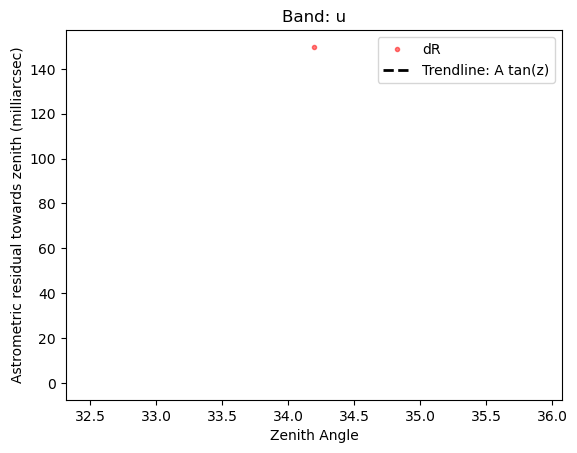

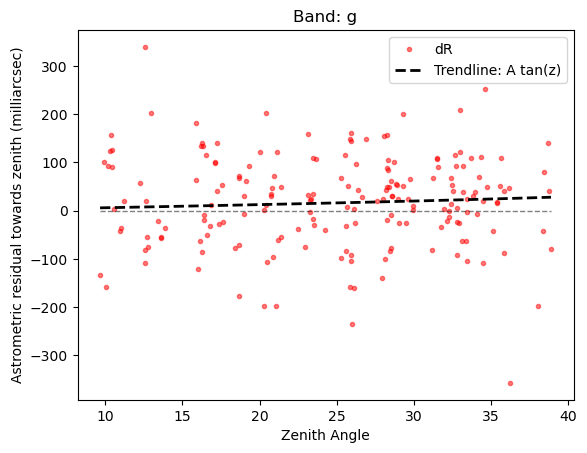

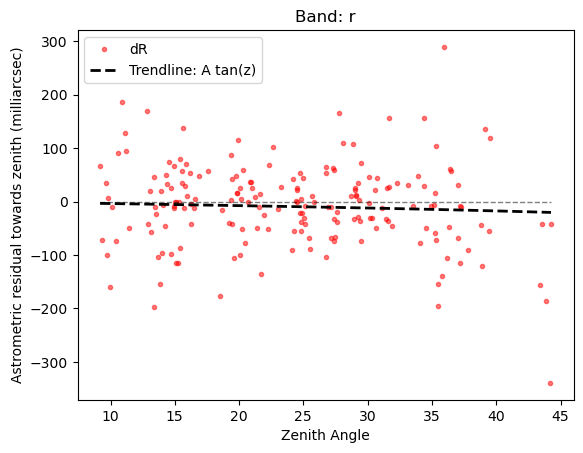

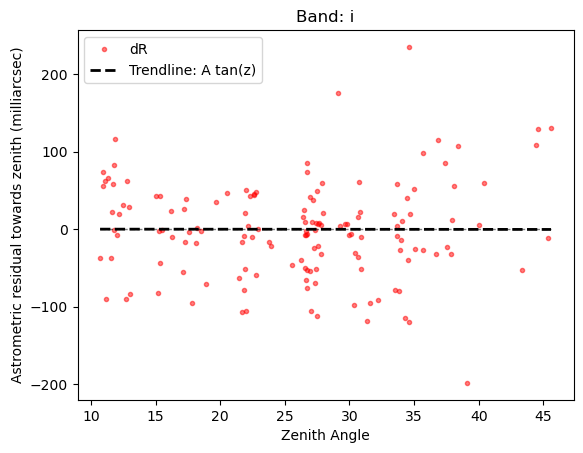

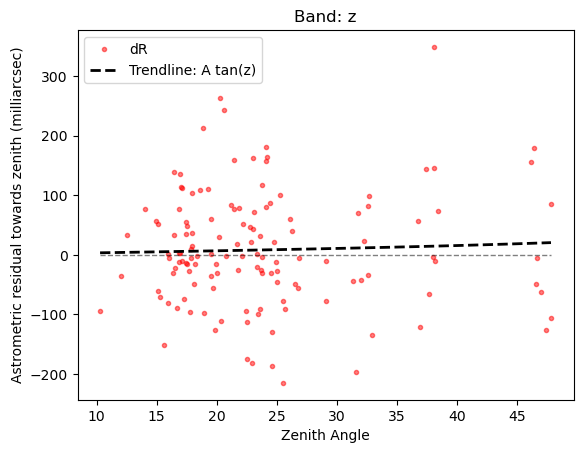

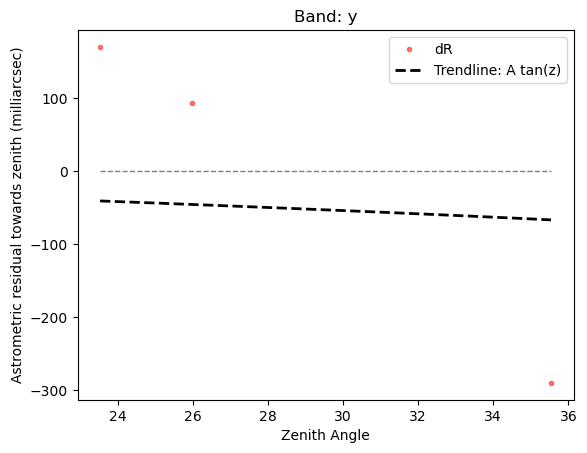

In [10]:
# Plot the residuals along the zenith direction vs zenith angle, for each band
# Also plot a trendline of the form A*tan(z)

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

for band in 'ugrizy':
    band_mask = master['band_1'] == band

    if np.sum(band_mask) > 0:

        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        
        dR = master['r_temp'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR)
        
        #plot dR in milliarcsec as a function of zenith angle
        plt.plot(z, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = 'dR')

        #plot a trendline
        z_temp = np.linspace(min(z), max(z), 20) 
        plt.plot(z_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = 'Trendline: A tan(z)')

        plt.plot(z_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()
        plt.show()
        plt.close()



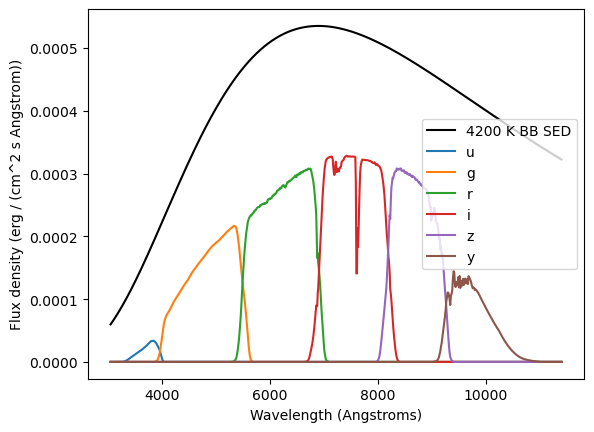

g-r color of source:  0.5232
1


/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_93601/4056752397.py:161: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(dR_model, z, dR)


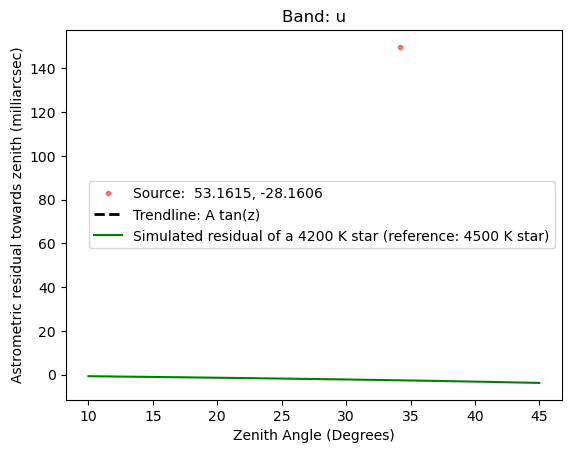

189


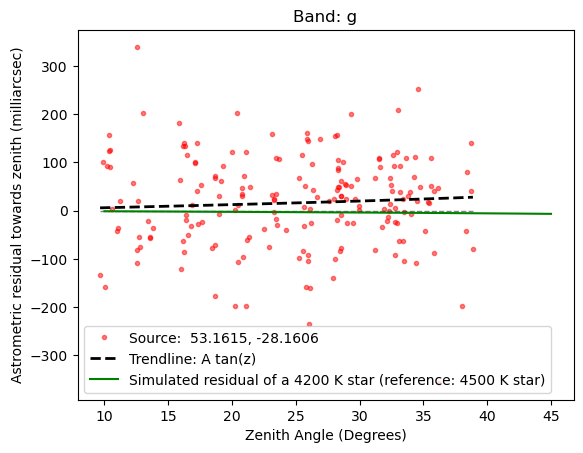

190


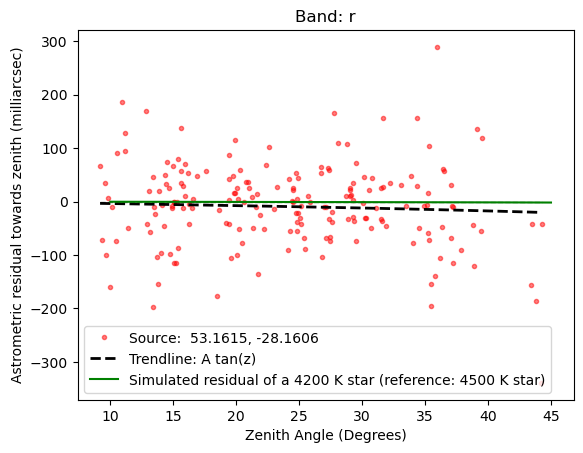

144


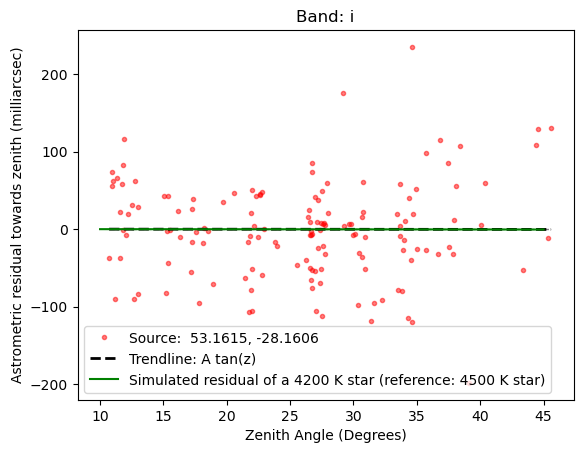

132


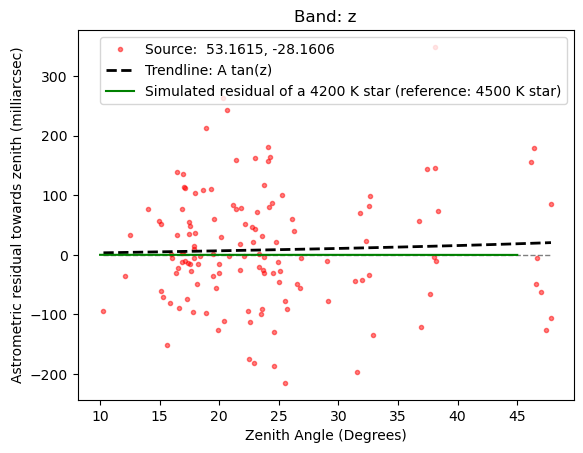

3


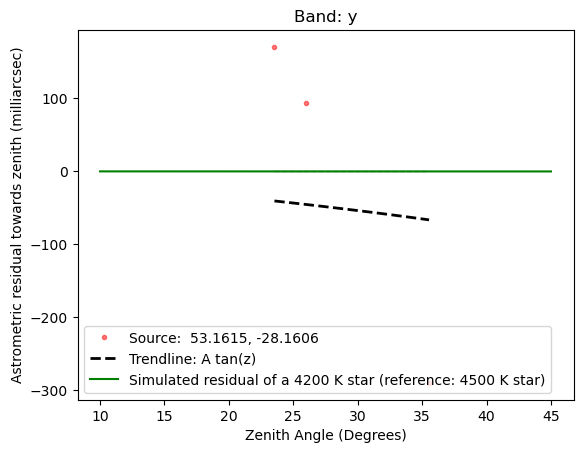

In [11]:
# Recreate the plots above but add a simulated model of the residuals
# The model uses a blackbody SED of a specified temperature as the source, and a second blackbody SED of a different temperature as the reference


from astropy.modeling.models import BlackBody
from astropy.constants import c
import astropy.units as u


def BB(wave, temp, scale):
    temp = temp * u.K
    wave = wave * u.AA
    scale = scale * u.erg / (u.cm**2 * u.s * u.AA * u.sr)

    bb = BlackBody(temperature = temp, scale = scale)
    return bb(wave).value


# Define the source and reference temperatures:
source_temperature = 4200 #K
reference_temperature = 4500 #K


wavelengths = np.logspace(np.log10(3050), np.log10(11400), num=1000) # Angstroms

plt.plot(wavelengths, BB(wavelengths, source_temperature, 1e-9), 'k-', label = f'{source_temperature} K BB SED')

filtered_bb = {}
Flux = {}

for band in 'ugrizy':
    fluxes = [BB(wavelengths, source_temperature, 1e-9), BB(wavelengths, reference_temperature, 1e-9),  np.ones(len(wavelengths))*np.max(BB(wavelengths, source_temperature, 1e-9))*0.1]
    filtered_bb[band]= apply_filter(wavelengths / 10, fluxes, band) # apply filter takes wavelengths in nm
    Flux[band] = integrate.simpson(filtered_bb[band][0], wavelengths)
    plt.plot(wavelengths, filtered_bb[band][0], label = f'{band}') # flux: {np.round(Flux[band], 4)}')

plt.legend()
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux density (erg / (cm^2 s Angstrom))')
plt.show()
plt.close()

gr_color = -2.5 * np.log10(Flux['g'] / Flux['r'])
print('g-r color of source: ', np.round(gr_color, 4))




# Calculate the DCR effect for a range of zenith angles

zeniths = np.linspace(10, 45, 10) #degrees

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067

def apply_DCR(wave, filtered_data, zenith, pressure, temperature, H2O_pressure):
    '''
    wave - list of wavelength points
    filtered_data - dictionary, keys: bands, items: list of flux throughputs for each SED as viewed in that band 

    Takes in SED data with the filter throughputs already applied, returns refraction_angles (mapped from wave) and filtered_refracted_data (the flux density over refraction angles)

    '''
    dwvl = 0.1 #wavelength step
    wave_temp = np.arange(290, 1160, dwvl)

    #Get dR/dwavelength function
    refraction = galsim.dcr.get_refraction(
        wave_temp,
        zenith_angle=zenith * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec

    dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
    wavelengths_midpoints = wave_temp[0:-1] + dwvl/2
    
    dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)

    #Get the refraction angle of each passed in wavelength 
    refraction_angles = galsim.dcr.get_refraction(
            wave,
            zenith_angle=zenith * galsim.degrees,
            pressure=pressure,  # kPa
            temperature=temperature,  # K
            H2O_pressure=H2O_pressure,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    
    filtered_refracted_data = {} #dictionary which will store dN/dR 
    
    for band, data in filtered_data.items():
        filtered_refracted_data[band] = np.abs(data / dRdwvl_func(wave))

    return refraction_angles, filtered_refracted_data

def weighted_avg_and_std(x_array, weights_dict):

    """
    Return the weighted average and standard deviation.

    values, weights -- Numpy ndarrays with the same shape.
    """
    x_transpose = np.array(x_array).T #create a vertical array for purposes of matrix multiplication below

    means = {}
    stdevs = {}

    for band, weights in weights_dict.items():
        mean = np.sum(weights * x_transpose, axis = 1)/np.sum(weights, axis =1)
        means[band] = mean
        stdevs[band] = np.sqrt(np.sum(weights * (x_transpose - mean[:, np.newaxis])**2, axis=1) / np.sum(weights, axis=1))

        # print(f'{band} (average): mean = {np.round(np.mean(mean), 4)}, stdev = {np.round(np.mean(stdevs[band]), 4)}')

    return means, stdevs

model_dR = {}
for band in 'ugrizy':
    model_dR[band] = np.array([])

model_stdevs = {}
for band in 'ugrizy':
    model_stdevs[band] = np.array([])

for zenith in zeniths:

    refraction_angles, filtered_refracted_data = apply_DCR(wavelengths/10, filtered_bb, zenith, pressure, temperature, H2O_pressure)

    means, stdevs = weighted_avg_and_std(refraction_angles, filtered_refracted_data)

    for band in 'ugrizy':
        model_dR[band] = np.append(model_dR[band], means[band][0] - means[band][1]) #difference between source and reference SEDs
        model_stdevs[band] = np.append(model_stdevs[band], stdevs[band][0]) #just the source SED stdev



    


# Plot the model results on top of the data

for band in 'ugrizy':
    band_mask = master['band_1'] == band

    if np.sum(band_mask) > 0:

        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi

        dR = master['r_temp'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR)
        print(len(dR))

        plt.plot(z, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
        z_temp = np.linspace(min(z), max(z), 20) 
        plt.plot(z_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = 'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        plt.plot(zeniths, model_dR[band] * 10**3 , 'g-', label = f'Simulated residual of a {source_temperature} K star (reference: {reference_temperature} K star)')
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle (Degrees)')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()
        plt.show()
        plt.close()